# 機械学習の基本コンセプト② パターン発見

## クラスタリング

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [3]:
url = 'http://files.grouplens.org/datasets/movielens/ml-100k/u.item'
movie_df= pd.read_csv(url, sep='|', header= None, encoding='latin-1')
movie_df.head()

,0,1,2,3,4,5,6,7,8,9,...,14,15,16,17,18,19,20,21,22,23
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [4]:
col_info = " id | movie title | release date | video release date | IMDb URL | unknown | Action | Adventure | Animation | Children's | Comedy | Crime | Documentary | Drama | Fantasy | Film-Noir | Horror | Musical | Mystery | Romance | Sci-Fi | Thriller | War | Western "

In [5]:
col_names = col_info.split("|")
movie_df.columns = col_names

In [6]:
movie_df.shape

(1682, 24)

In [7]:
X = movie_df[col_names[5:]]

In [8]:
from sklearn.cluster import KMeans

In [9]:
kmeans = KMeans(n_clusters=4, random_state=0).fit(X)

In [10]:
movie_df['cluster_label'] = kmeans.labels_
movie_df.head()

,id,movie title,release date,video release date,IMDb URL,unknown,Action,Adventure,Animation,Children's,...,Film-Noir,Horror,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,cluster_label
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,1
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,1,0,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,3
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,2
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,1,0,0,2


In [11]:
label_size = movie_df['cluster_label'].value_counts().sort_index()
label_size

cluster_label
0    212
1    107
2    704
3    659
Name: count, dtype: int64

In [12]:
label_size/label_size.sum()

cluster_label
0    0.126040
1    0.063615
2    0.418549
3    0.391795
Name: count, dtype: float64

In [13]:
cluster_genre_df = movie_df[col_names[5:] + ['cluster_label']].groupby('cluster_label').sum().T
cluster_genre_df

cluster_label,0,1,2,3
unknown,0,0,0,2
Action,197,6,32,16
Adventure,77,40,5,13
Animation,3,32,0,7
Children's,3,107,12,0
Comedy,13,41,87,364
Crime,17,0,47,45
Documentary,0,0,3,47
Drama,14,7,704,0
Fantasy,2,12,4,4


In [14]:
cluster_genre_df / cluster_genre_df.sum()

cluster_label,0,1,2,3
unknown,0.000000,0.000000,0.000000,0.002121
Action,0.356239,0.021661,0.028571,0.016967
Adventure,0.139241,0.144404,0.004464,0.013786
Animation,0.005425,0.115523,0.000000,0.007423
Children's,0.005425,0.386282,0.010714,0.000000
Comedy,0.023508,0.148014,0.077679,0.386002
Crime,0.030741,0.000000,0.041964,0.047720
Documentary,0.000000,0.000000,0.002679,0.049841
Drama,0.025316,0.025271,0.628571,0.000000
Fantasy,0.003617,0.043321,0.003571,0.004242


<Axes: xlabel='cluster_label'>

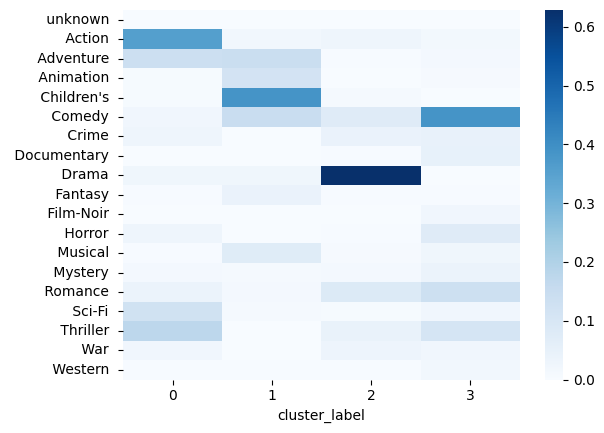

In [15]:
sns.heatmap((cluster_genre_df / cluster_genre_df.sum()), cmap='Blues')

## 次元圧縮（次元削減）

In [18]:
X = movie_df[col_names[5:]]

In [19]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

In [20]:
X_pca

array([[-0.8060077 ,  0.41113905],
       [-0.34032161, -1.30357842],
       [-0.1588431 , -0.60255462],
       ...,
       [ 0.62455099,  0.31059912],
       [-0.69656162,  0.43908311],
       [ 0.67125233,  0.15619308]], shape=(1682, 2))

In [21]:
print("分散説明率",pca.explained_variance_ratio_)
print("累積分散説明率",pca.explained_variance_ratio_.sum())

分散説明率 [0.2315764  0.17370217]
累積分散説明率 0.40527857405114365


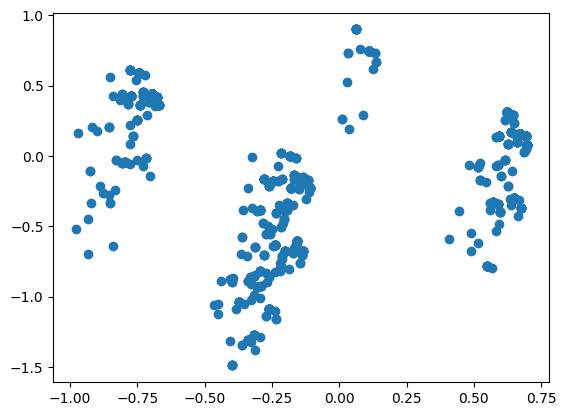

In [22]:
plt.scatter(x=X_pca[:,0], y=X_pca[:,1])

In [25]:
pca_movie_df = movie_df[[' movie title ']]
pca_movie_df['pca1'] = X_pca[:,0]
pca_movie_df['pca2'] = X_pca[:,1]

/var/folders/rp/r7rm8rzn5mvdkpykf4c15d540000gn/T/ipykernel_1036/3380410786.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pca_movie_df['pca1'] = X_pca[:,0]
/var/folders/rp/r7rm8rzn5mvdkpykf4c15d540000gn/T/ipykernel_1036/3380410786.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pca_movie_df['pca2'] = X_pca[:,1]


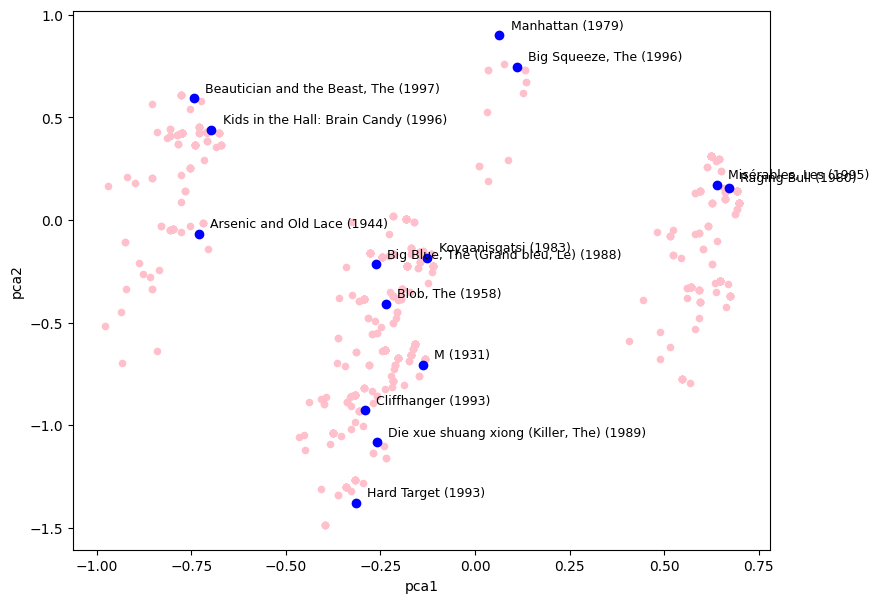

In [27]:
pca_movie_df.plot(kind='scatter', x='pca1', y='pca2',figsize=(9,7),color='pink')
sampled_movie_df = pca_movie_df.sample(14,random_state=0)
plt.scatter(x=sampled_movie_df['pca1'], y=sampled_movie_df['pca2'],color='blue')
for i, row in sampled_movie_df.iterrows():
  x,y, title = row.pca1, row.pca2, row[' movie title ']
  plt.text(x+.03,y+.03, title, fontsize=9)

In [29]:
def cos_sim(v1,v2):
  return np.dot(v1,v2)/(np.linalg.norm(v1) * np.linalg.norm(v2))

In [31]:
movie_name = 'Toy Story (1995)'
movie_vector = pca_movie_df[pca_movie_df[' movie title '] == movie_name][['pca1','pca2']].values[0,:]
movie_vector

array([-0.8060077 ,  0.41113905])

In [32]:
similarities = []
for k, row in pca_movie_df[['pca1','pca2']].iterrows():
  v= [row.pca1, row.pca2]
  similarity = cos_sim(movie_vector,v)
  similarities.append(similarity)

pca_movie_df['cos_sim'] = np.array(similarities)

/var/folders/rp/r7rm8rzn5mvdkpykf4c15d540000gn/T/ipykernel_1036/802559031.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  pca_movie_df['cos_sim'] = np.array(similarities)


In [34]:
pca_movie_df.sort_values(by='cos_sim',ascending=False).head(10)

,movie title,pca1,pca2,cos_sim
0,Toy Story (1995),-0.806008,0.411139,1.000000
421,Aladdin and the King of Thieves (1996),-0.806008,0.411139,1.000000
94,Aladdin (1992),-0.838953,0.426681,0.999999
71,"Mask, The (1994)",-0.684300,0.355007,0.999976
636,"Howling, The (1981)",-0.740526,0.366843,0.999931
1198,Cemetery Man (Dellamorte Dellamore) (1994),-0.740526,0.366843,0.999931
207,Young Frankenstein (1974),-0.740526,0.366843,0.999931
1051,Dracula: Dead and Loving It (1995),-0.740526,0.366843,0.999931
122,"Frighteners, The (1996)",-0.740526,0.366843,0.999931
1370,"Machine, The (1994)",-0.740526,0.366843,0.999931
